In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

โหลดข้อมูล

In [2]:
df = pd.read_csv('protein_no_duplicates-2.csv')

ดูข้อมูลพื้นฐาน

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44008 entries, 0 to 44007
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RMSD    44008 non-null  float64
 1   F1      44008 non-null  float64
 2   F2      44008 non-null  float64
 3   F3      44008 non-null  float64
 4   F4      44008 non-null  float64
 5   F5      44008 non-null  float64
 6   F6      44008 non-null  float64
 7   F7      44008 non-null  float64
 8   F8      44008 non-null  float64
 9   F9      44008 non-null  float64
dtypes: float64(10)
memory usage: 3.4 MB


ดูข้อมูล5แถวแรก

In [4]:
df.head()

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102.0,27.0302
1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39.0,38.5468
2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29.0,38.8119
3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70.0,39.0651
4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41.0,39.9147


ตรวจสอบค่าซ้ำ

In [5]:
duplicates = df.duplicated().sum()
print(f"จำนวนแถวที่ซ้ำกันทั้งหมด: {duplicates} แถว")

จำนวนแถวที่ซ้ำกันทั้งหมด: 0 แถว


ตรวจสอบค่าว่าง

In [7]:
missing_values = df.isnull().sum()
print(missing_values)

RMSD    0
F1      0
F2      0
F3      0
F4      0
F5      0
F6      0
F7      0
F8      0
F9      0
dtype: int64


รวจสอบOutliers ด้วยวิธี IQR แสดงด้วยbox plot

Outliers count per column:
RMSD: 0
F1: 1104
F2: 1189
F3: 0
F4: 1165
F5: 1018
F6: 1239
F7: 525
F8: 0
F9: 137


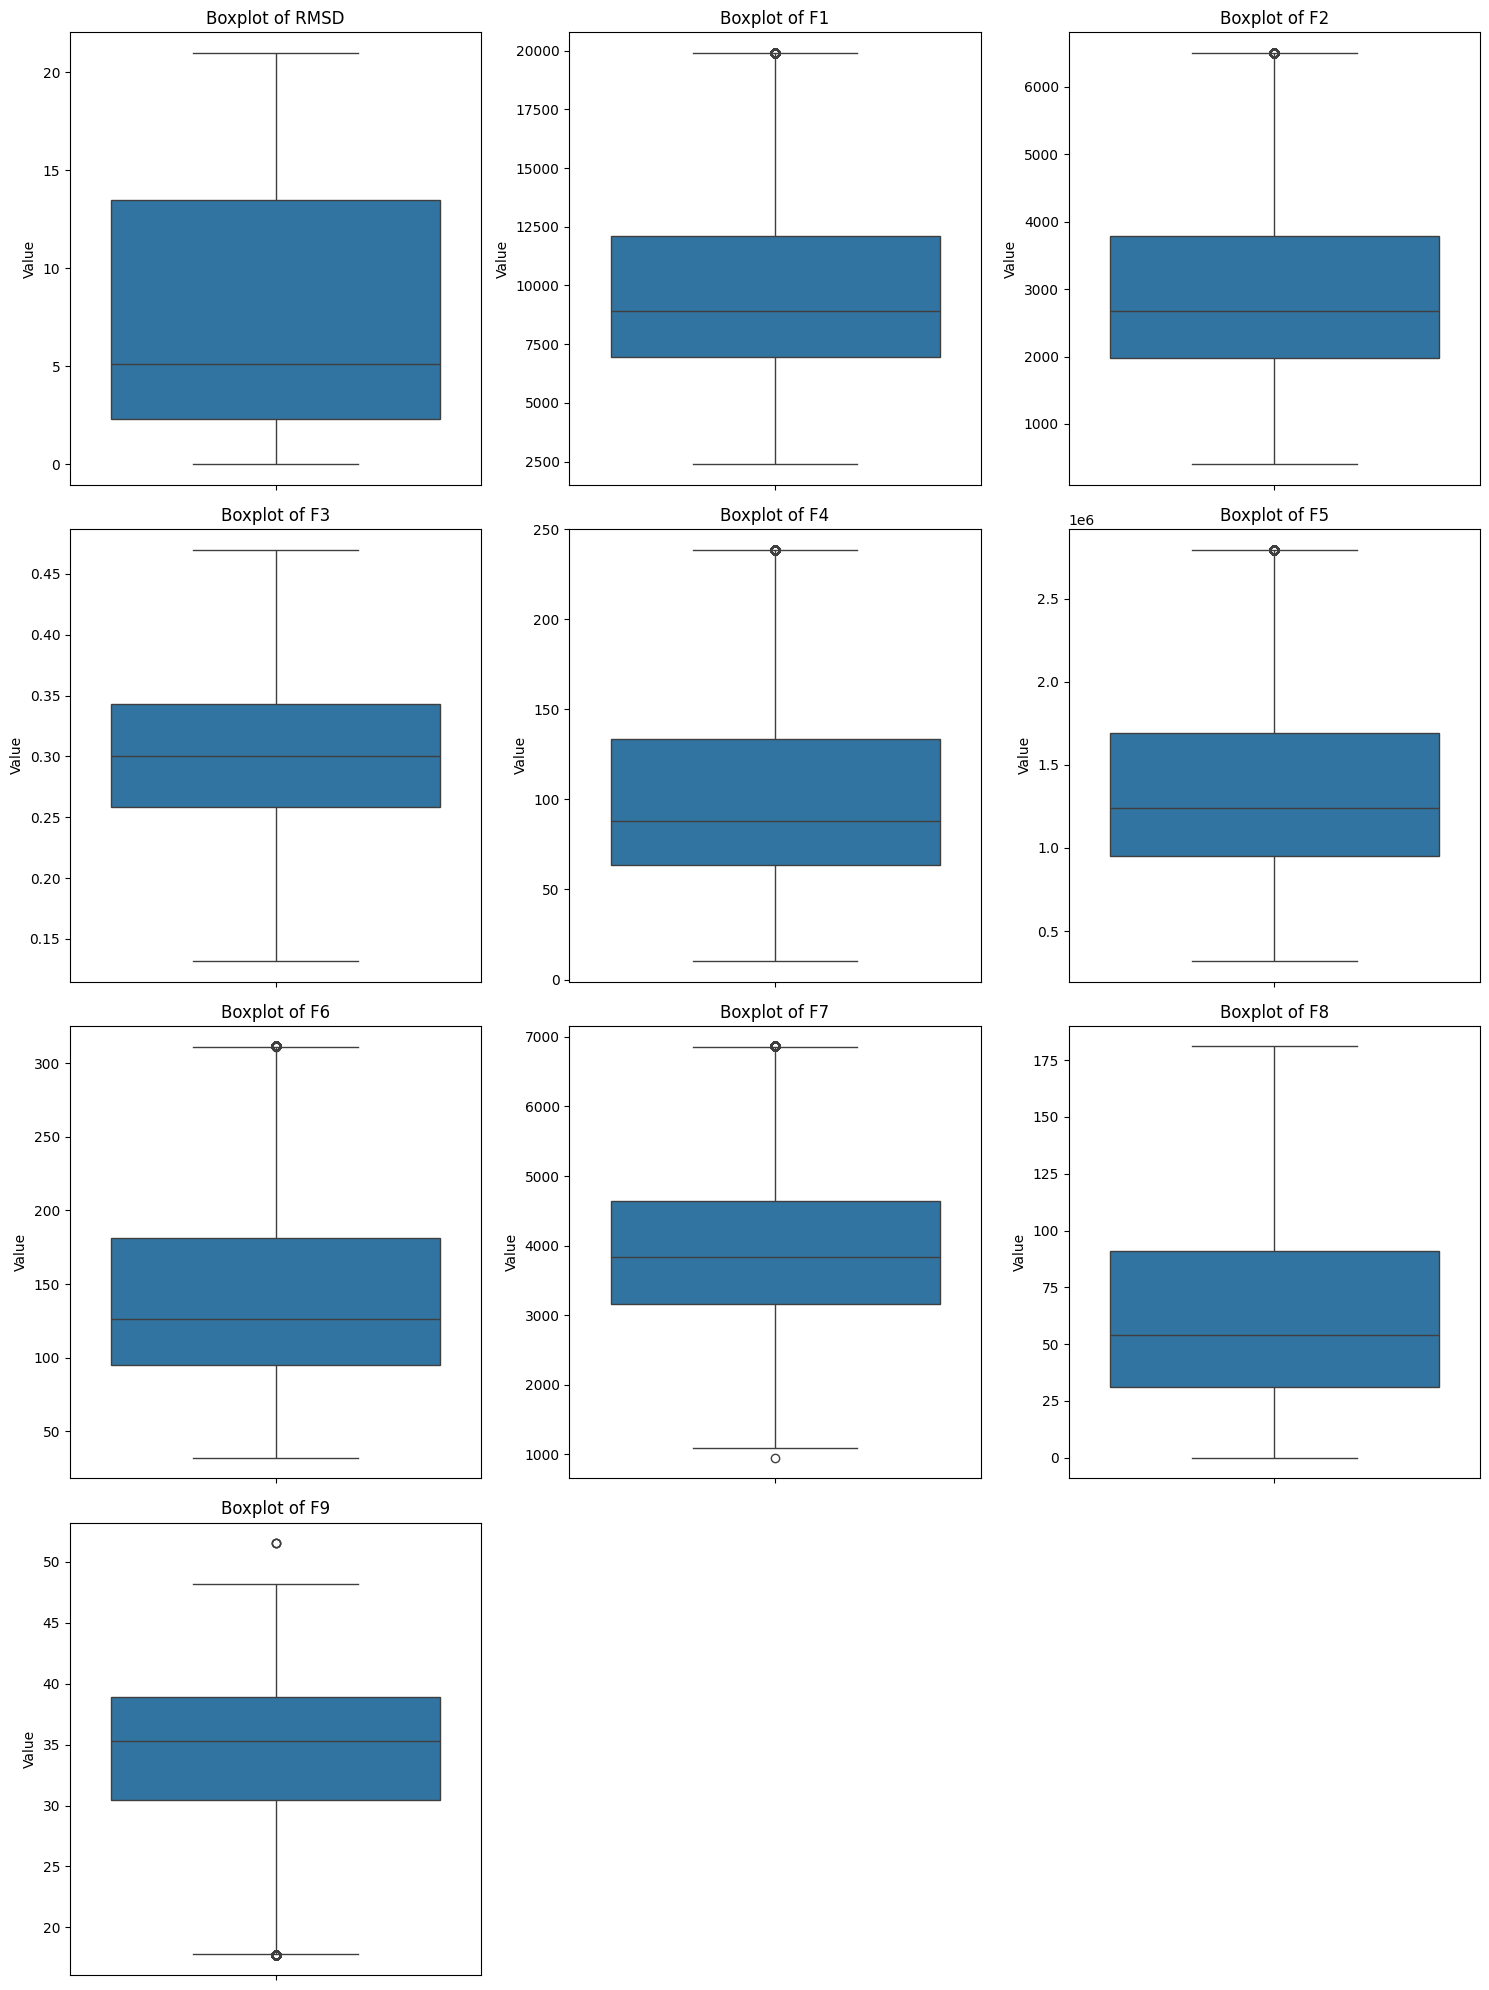

In [11]:
numeric_cols = df.select_dtypes(include=['number']).columns

num_cols = 3
num_rows = (len(numeric_cols) + num_cols - 1) // num_cols


fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('Value')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('boxplots.png')


def check_outliers_iqr(df):
    outliers_report = {}
    numeric_cols = df.select_dtypes(include=['number']).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
        outliers_report[col] = outliers_count
    return outliers_report

outliers = check_outliers_iqr(df)
print("Outliers count per column:")
for col, count in outliers.items():
    print(f"{col}: {count}")

ดูความสัมพันธ์ของข้อมูลแต่ละตัวแปรโดยใช้Correlation Heatmap

          RMSD        F1        F2        F3        F4        F5        F6  \
RMSD  1.000000 -0.011871  0.157158  0.373129 -0.165078 -0.011287 -0.030917   
F1   -0.011871  1.000000  0.905528  0.130846  0.935112  0.998115  0.967310   
F2    0.157158  0.905528  1.000000  0.514161  0.805580  0.901821  0.911359   
F3    0.373129  0.130846  0.514161  1.000000  0.038991  0.127011  0.209462   
F4   -0.165078  0.935112  0.805580  0.038991  1.000000  0.929749  0.941255   
F5   -0.011287  0.998115  0.901821  0.127011  0.929749  1.000000  0.961135   
F6   -0.030917  0.967310  0.911359  0.209462  0.941255  0.961135  1.000000   
F7   -0.010698  0.897427  0.812708  0.112233  0.829315  0.896007  0.864817   
F8    0.028939  0.658145  0.598012  0.110214  0.671017  0.651263  0.671407   
F9    0.061401 -0.907247 -0.800135 -0.071894 -0.896407 -0.905729 -0.889111   

            F7        F8        F9  
RMSD -0.010698  0.028939  0.061401  
F1    0.897427  0.658145 -0.907247  
F2    0.812708  0.598012 -0.80

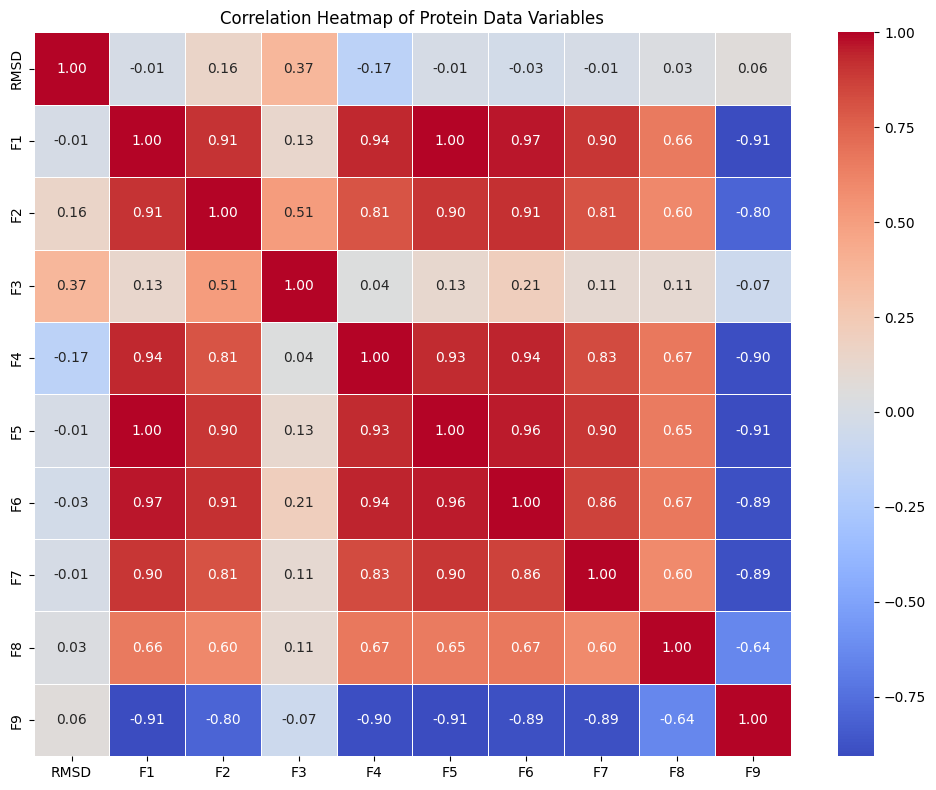

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


corr_matrix = df.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Protein Data Variables')
plt.tight_layout()


print(corr_matrix)

ค่าที่เราต้องการจะทำนายหาคือค่าRMSD

ตัวแปรxที่เลือกมามีดังนี้F9, F6, F1 และ F3

F9 และ F6 เลือกเนื่องจาก มีค่าความสัมพันธ์สูงที่สุด (ประมาณ 0.49 - 0.51) ซึ่งถือเป็น ตัวแปรหลัก ที่มีอิทธิพลต่อการขึ้นลงของค่า RMSD อย่างชัดเจน

F1 และ F3 เลือกเนื่องจาก มีค่าความสัมพันธ์รองลงมา (ประมาณ 0.37) ซึ่งยังอยู่ในเกณฑ์ที่มีนัยสำคัญในการนำมาช่วยทำนาย

F9: มีความสัมพันธ์เชิงลบ Negative Correlation หมายถึงถ้า F9 มีค่าสูง ค่า RMSD จะมีแนวโน้มต่ำลง

F6, F1, F3: มีความสัมพันธ์เชิงบวก Positive Correlation หมายถึงถ้าตัวแปรเหล่านี้เพิ่มขึ้น ค่า RMSD จะเพิ่มขึ้นตาม การเลือกตัวแปรที่มีทิศทางความสัมพันธ์ที่หลากหลายจะช่วยให้โมเดลสามารถเรียนรู้ความซับซ้อนของข้อมูลได้ครอบคลุมมากขึ้น

ทำการเปรียบเทียบโมเดล3โมเดล 1.Random Forest 2.Support Vector Machine 3.Gradient Boosting และใช้confution matrix เพื่อแสดงผลการทำนายแต่ละโมเดล แสดงค่าaccuracy และ F1Score ของแต่ละโมเดล

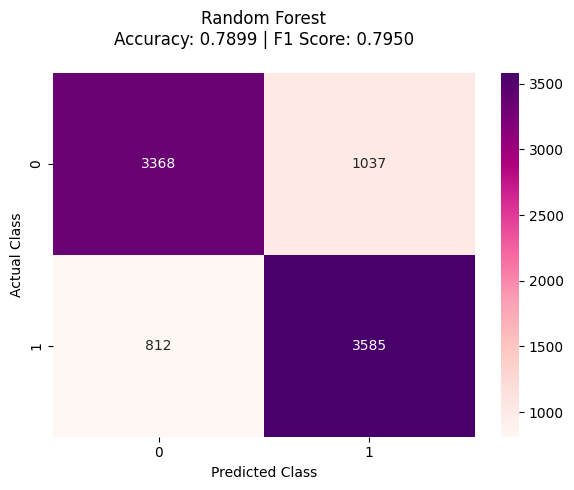

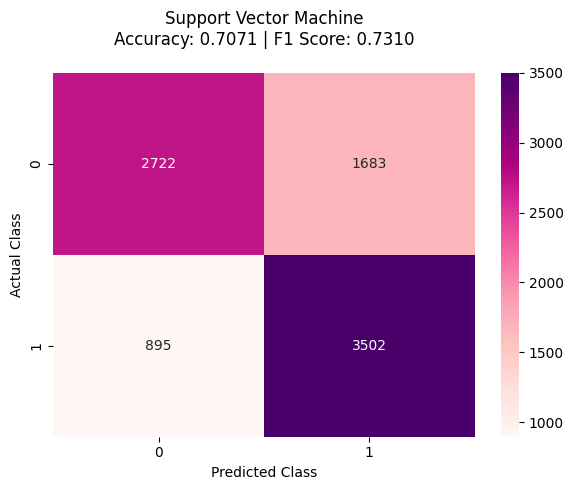

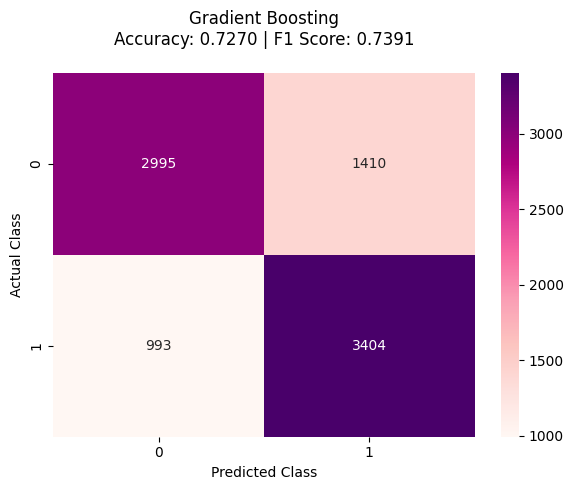

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler


# กำหนด x = F9, F6, F1, F3 และ y = RMSD
df = pd.read_csv('protein_no_duplicates-2.csv')
median_rmsd = df['RMSD'].median()
df['RMSD_class'] = (df['RMSD'] >= median_rmsd).astype(int)

X = df[['F9', 'F6', 'F1', 'F3']]
y = df['RMSD_class']

# 2. Scaling ข้อมูล (จำเป็นมากสำหรับ SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # สร้างรูปกราฟ
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu')

    # แสดงค่า Accuracy และ F1
    plt.title(f'{name}\nAccuracy: {acc:.4f} | F1 Score: {f1:.4f}', fontsize=12, pad=20)
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()


    plt.show()

เลือกโมเดลRandom Forest เนื่องจากมีค่าAccuracyและF1 Score มากที่สุดจึงเลือกโมเดลRandom Forest อีกทั้งยังสามารถใช้งานง่ายไม่ยุ่งยาก